In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/sample_data/SeoulBikeData.csv', encoding='ISO-8859-1')
print(df.head())


         Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
0  01/12/2017                254     0             -5.2           37   
1  01/12/2017                204     1             -5.5           38   
2  01/12/2017                173     2             -6.0           39   
3  01/12/2017                107     3             -6.2           40   
4  01/12/2017                 78     4             -6.0           36   

   Wind speed (m/s)  Visibility (10m)  Dew point temperature(°C)  \
0               2.2              2000                      -17.6   
1               0.8              2000                      -17.6   
2               1.0              2000                      -17.7   
3               0.9              2000                      -17.6   
4               2.3              2000                      -18.6   

   Solar Radiation (MJ/m2)  Rainfall(mm)  Snowfall (cm) Seasons     Holiday  \
0                      0.0           0.0            0.0  Winter  No Holiday   


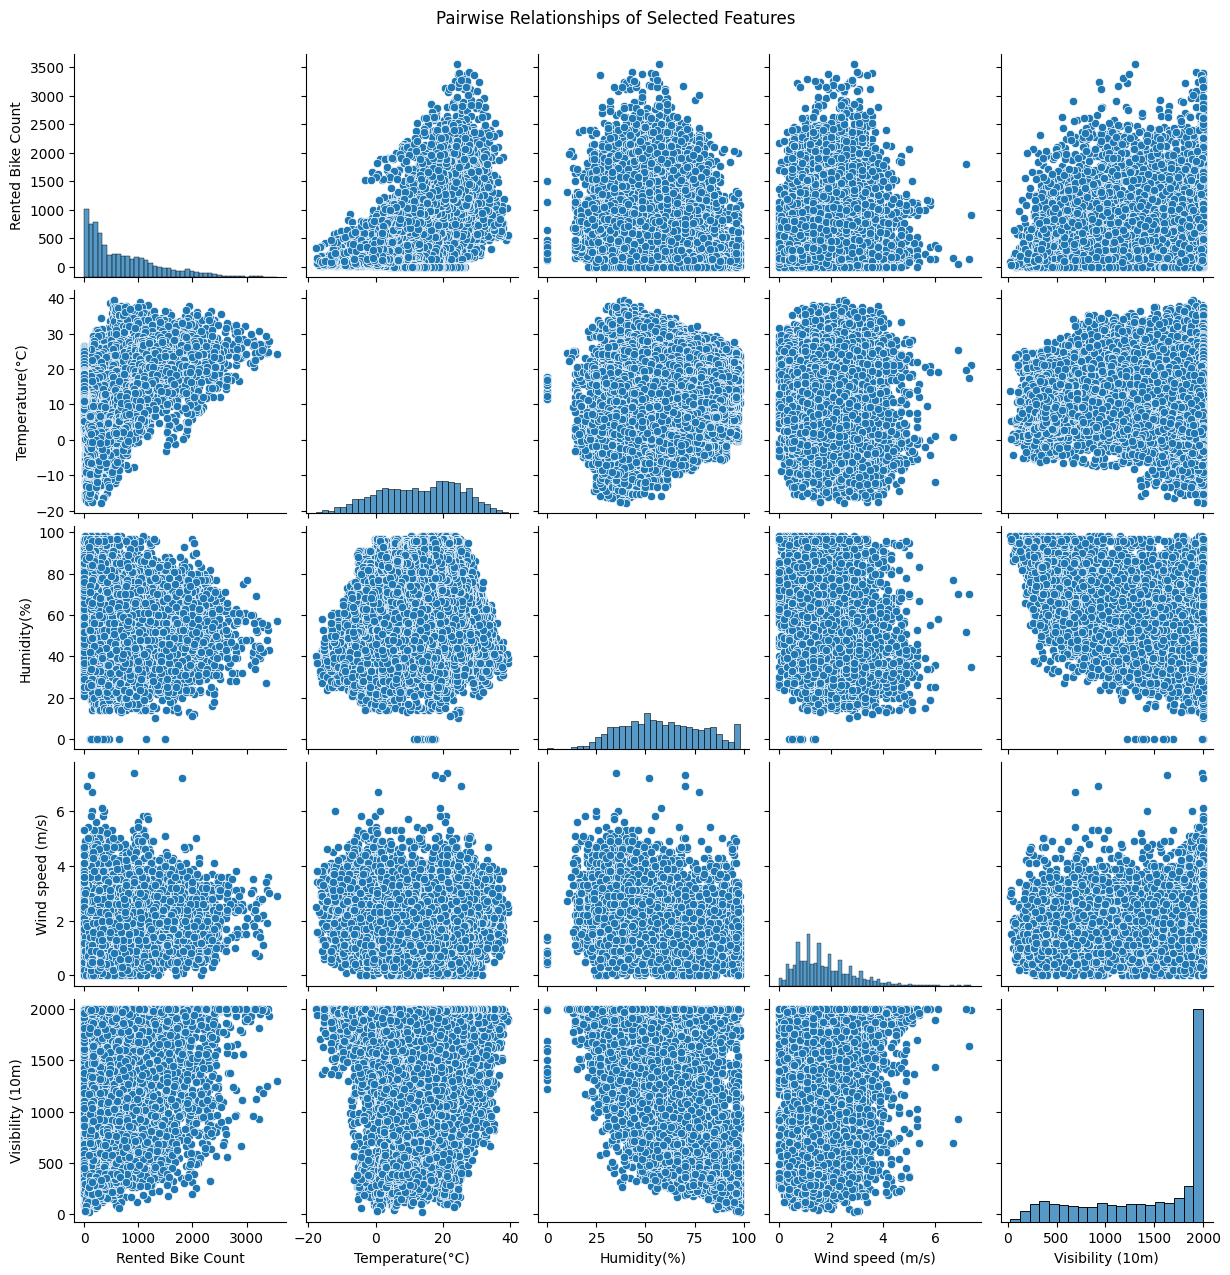

In [9]:
selected_features = ['Rented Bike Count', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)']

sns.pairplot(df[selected_features])
plt.suptitle("Pairwise Relationships of Selected Features", y=1.02)
plt.show()

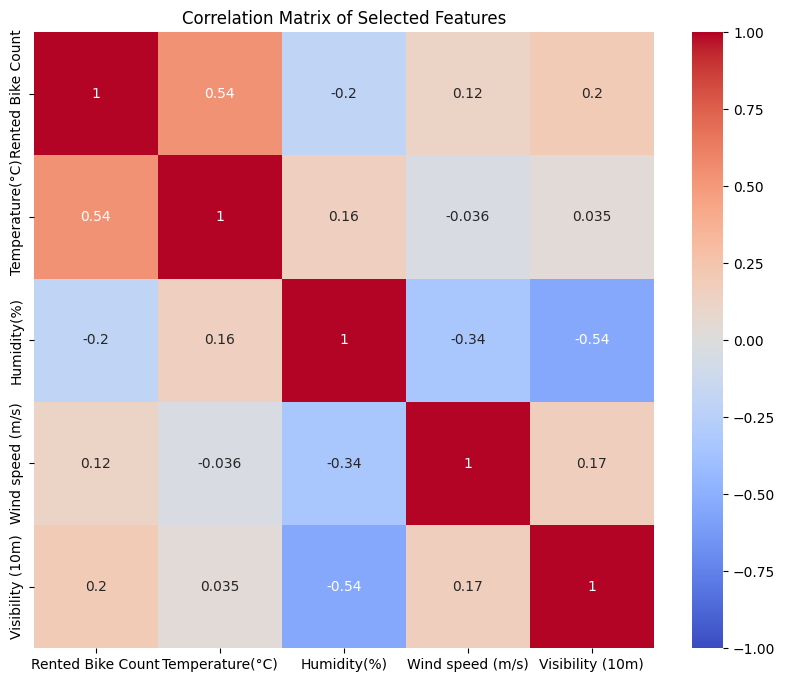

In [3]:

selected_features = ['Rented Bike Count', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)']

correlation_matrix = df[selected_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Selected Features")
plt.show()


Correlation of each feature with Rented Bike Count:

                   Rented Bike Count
Rented Bike Count           1.000000
Temperature(°C)             0.538558
Visibility (10m)            0.199280
Wind speed (m/s)            0.121108
Humidity(%)                -0.199780


<ipython-input-4-95c3baa0e4ee>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rented_bike_corr.index, y=rented_bike_corr['Rented Bike Count'], palette='viridis')


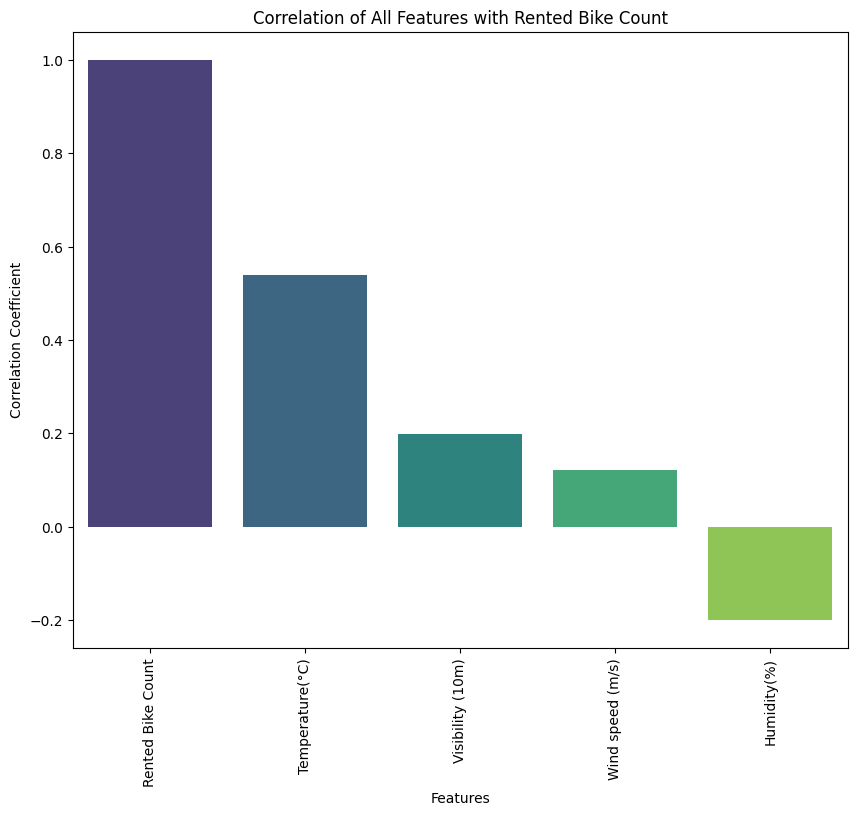

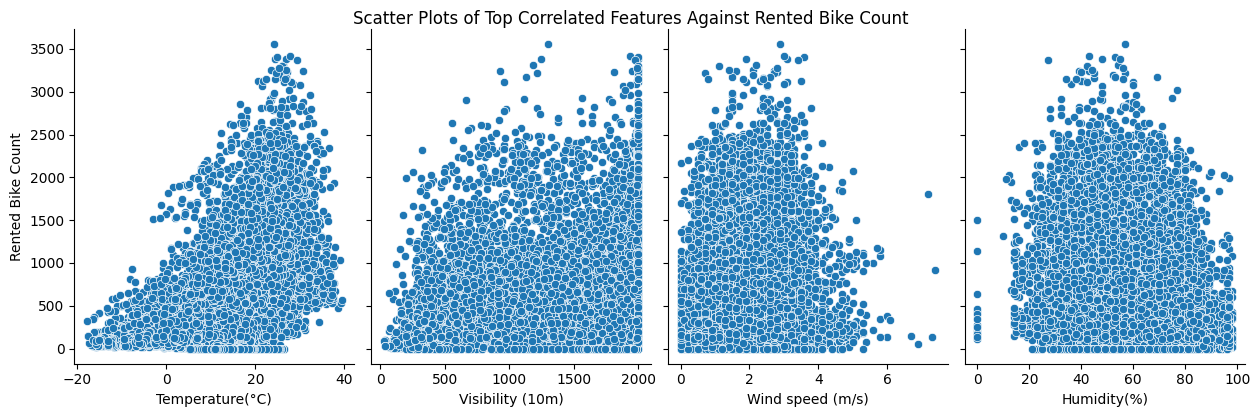

In [4]:


rented_bike_corr = correlation_matrix[['Rented Bike Count']].sort_values(by='Rented Bike Count', ascending=False)

print("Correlation of each feature with Rented Bike Count:\n")
print(rented_bike_corr)

plt.figure(figsize=(10, 8))
sns.barplot(x=rented_bike_corr.index, y=rented_bike_corr['Rented Bike Count'], palette='viridis')
plt.xticks(rotation=90)
plt.title("Correlation of All Features with Rented Bike Count")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.show()

top_features = rented_bike_corr.index[1:6]

sns.pairplot(df, x_vars=top_features, y_vars='Rented Bike Count', height=4, aspect=0.8, kind='scatter')
plt.suptitle("Scatter Plots of Top Correlated Features Against Rented Bike Count", y=1.02)
plt.show()


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df.drop(columns=['Date'], inplace=True)

df = pd.get_dummies(df, drop_first=True)

X = df.drop(columns=['Rented Bike Count'])
y = df['Rented Bike Count']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, random_state=42)

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 6131
Validation set size: 1315
Test set size: 1314


# New Section

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_val_pred_linear = linear_model.predict(X_val_scaled)
linear_mse = mean_squared_error(y_val, y_val_pred_linear)
linear_r2 = r2_score(y_val, y_val_pred_linear)

print("Linear Regression - Validation Set:")
print("Mean Squared Error:", linear_mse)
print("R-squared:", linear_r2)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_val_pred_rf = rf_model.predict(X_val_scaled)
rf_mse = mean_squared_error(y_val, y_val_pred_rf)
rf_r2 = r2_score(y_val, y_val_pred_rf)

print("\nRandom Forest Regression - Validation Set:")
print("Mean Squared Error:", rf_mse)
print("R-squared:", rf_r2)

y_test_pred_linear = linear_model.predict(X_test_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

test_mse_linear = mean_squared_error(y_test, y_test_pred_linear)
test_r2_linear = r2_score(y_test, y_test_pred_linear)

test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("\nLinear Regression - Test Set:")
print("Mean Squared Error:", test_mse_linear)
print("R-squared:", test_r2_linear)

print("\nRandom Forest Regression - Test Set:")
print("Mean Squared Error:", test_mse_rf)
print("R-squared:", test_r2_rf)


Linear Regression - Validation Set:
Mean Squared Error: 179606.51967837714
R-squared: 0.5613522424872284

Random Forest Regression - Validation Set:
Mean Squared Error: 49049.29722053232
R-squared: 0.8802083339074124

Linear Regression - Test Set:
Mean Squared Error: 187560.5152171297
R-squared: 0.5457655010677662

Random Forest Regression - Test Set:
Mean Squared Error: 51163.09397427701
R-squared: 0.8760930981218268


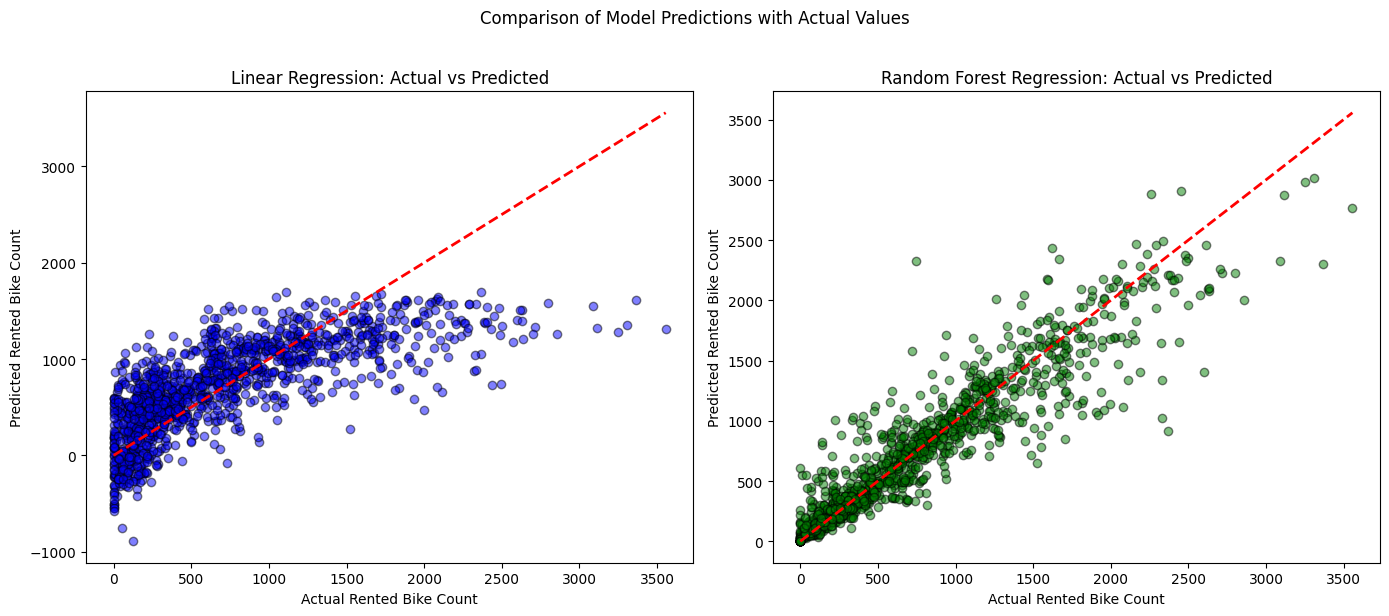

In [12]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred_linear, alpha=0.5, color='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rented Bike Count')
plt.ylabel('Predicted Rented Bike Count')
plt.title('Linear Regression: Actual vs Predicted')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred_rf, alpha=0.5, color='green', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rented Bike Count')
plt.ylabel('Predicted Rented Bike Count')
plt.title('Random Forest Regression: Actual vs Predicted')

plt.suptitle("Comparison of Model Predictions with Actual Values", y=1.02)
plt.tight_layout()
plt.show()



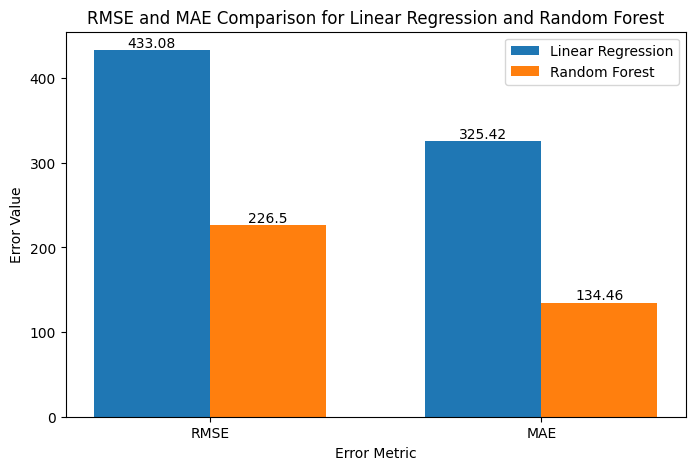

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt


rmse_linear = np.sqrt(mean_squared_error(y_test, y_test_pred_linear))
mae_linear = mean_absolute_error(y_test, y_test_pred_linear)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
mae_rf = mean_absolute_error(y_test, y_test_pred_rf)

metrics = ['RMSE', 'MAE']
linear_scores = [rmse_linear, mae_linear]
rf_scores = [rmse_rf, mae_rf]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, linear_scores, width, label='Linear Regression')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest')

ax.set_xlabel('Error Metric')
ax.set_ylabel('Error Value')
ax.set_title('RMSE and MAE Comparison for Linear Regression and Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.show()


The bar plot compares the Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) for Linear Regression and Random Forest models, showing how well each model predicts the rented bike count:

Linear Regression has an RMSE of 433.08, while Random Forest has a lower RMSE of 226.5.
RMSE measures the average magnitude of prediction errors, with larger errors weighted more heavily due to squaring. The lower RMSE for Random Forest indicates that its predictions are generally closer to the actual bike counts, handling larger errors better than Linear Regression.

Linear Regression has an MAE of 325.42, whereas Random Forest achieves a lower MAE of 134.46.
MAE gives the average absolute difference between predictions and actual values. The lower MAE for Random Forest suggests it consistently produces more accurate predictions with smaller average errors compared to Linear Regression.

Random Forest performs significantly better than Linear Regression on both RMSE and MAE metrics, indicating it is a more accurate model for this dataset. The complex, nonlinear relationships in the data are likely captured well by Random Forest, whereas Linear Regression, which assumes linear relationships, struggles to accurately model these patterns.

Thus,
Random Forest is a better choice for predicting bike rentals due to its ability to handle complex relationships, leading to more accurate and reliable predictions.




MSE = 179,606, R² = 0.561
MSE = 187,560, R² = 0.546
Linear Regression has a moderate R² score (around 0.55), meaning it explains roughly 55% of the variance in the bike demand data. However, the relatively high MSE indicates that it is not a very accurate model for this data, likely because the relationship between features and bike demand may be nonlinear, which linear regression cannot capture effectively.

MSE = 49,147, R² = 0.880
MSE = 51,300, R² = 0.876
Random Forest performs significantly better, with a much lower MSE and a high R² of around 0.88 on both validation and test sets. This indicates that Random Forest can capture more complex, nonlinear relationships in the data, making it a better fit for predicting bike demand.

Random Forest is clearly the better model in this case, as it achieves much higher accuracy (lower MSE and higher R²) than Linear Regression on both validation and test sets.
The results suggest that the bike demand data has a complex, possibly nonlinear relationship with the input features, which Random Forest (an ensemble model) is better suited to handle.

In summary, Random Forest Regression is a more suitable choice here given its strong performance, while Linear Regression might be too simplistic for this dataset.

6) Quantify how good a job each method did in predicting the value of the dependent variable (using your test data set). Discuss why you believe each method performed as it did.





MSE for test set 187,560 -This high value indicates a considerable error in the model’s predictions, meaning that Linear Regression often deviates significantly from the actual rented bike counts.
R² value 0.546 — This value suggests that Linear Regression explains only about 54.6% of the variance in bike rentals, implying that it captures some but not all factors affecting bike demand.
  
Linear Regression assumes a linear relationship between the features and bike demand. However, bike rentals are influenced by more complex, nonlinear factors (e.g., seasonality, weather variations). This limitation prevents Linear Regression from fully capturing the demand pattern, leading to higher prediction errors and moderate R².


MSE for test set: 51,300 — This much lower MSE indicates that Random Forest’s predictions are closer to actual values, making it a more accurate model.
R² value 0.876 — This high R² score means that Random Forest explains 87.6% of the variance in bike rentals, showing it captures a substantial part of the patterns in the data.
  
Random Forest can model complex, nonlinear relationships and feature interactions, which are likely present in bike rental demand. Additionally, it’s robust to outliers and noise, allowing it to generalize well on the test set. These characteristics make Random Forest well-suited to this dataset, as it effectively models the factors influencing bike rentals.

Random Forest significantly outperformed Linear Regression, achieving higher accuracy and better fit due to its ability to capture nonlinear relationships and interactions among features. Linear Regression’s simplistic approach was insufficient for modeling the complex patterns in bike demand, leading to lower performance.